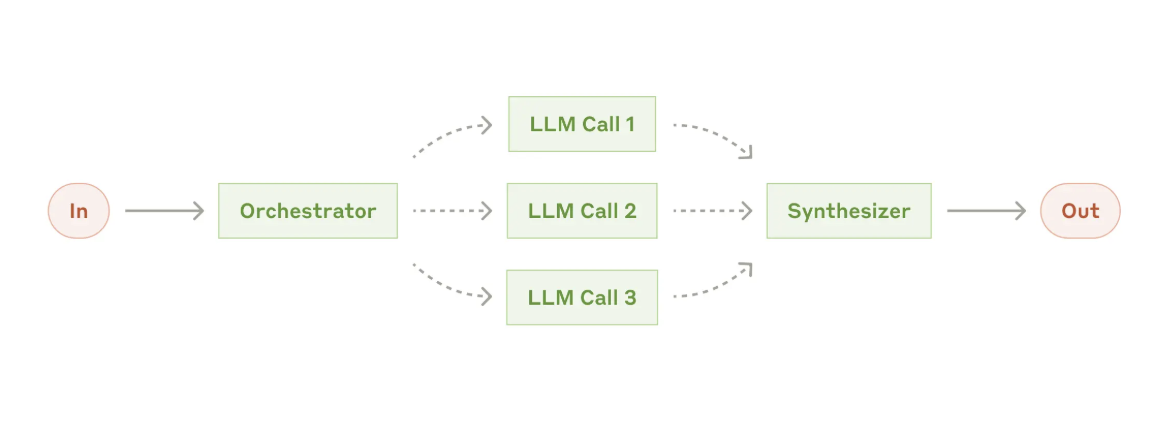

<a href="https://langchain-ai.github.io/langgraph/tutorials/workflows/">Source</a>

# 0.0. Configure

In [1]:
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

# 1.0. Import

In [24]:
from IPython.display import Image, display
from pydantic import BaseModel, Field

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langgraph.constants import Send

from langchain_core.messages import HumanMessage, SystemMessage

from typing import Annotated, List
import operator

# 2.0. Hands-On

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
class Section(BaseModel):
    name: str = Field(None, description="The name of the section of the report.")
    description: str = Field(None, description="Brief overview of the main topics and concepts to be covered in this section.")

class Sections(BaseModel):
    sections: List[Section] = Field(None, description="Section of the report")

In [ ]:
planner = llm.with_structured_output(Sections)

In [10]:
class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated[list, operator.add]
    final_report: str

class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [8]:
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return { "sections": report_sections.sections }

In [19]:
orchestrator(State(
    topic="The impact of climate change on the economy",
    sections=[],
    completed_sections=[],
    final_report=""
))

{'sections': [Section(name='Introduction', description='Overview of climate change and its significance to global economies.'),
  Section(name='Economic Impacts of Climate Change', description='Analysis of how climate change affects various sectors of the economy, including agriculture, tourism, and manufacturing.'),
  Section(name='Cost of Inaction', description='Discussion on the economic consequences of failing to address climate change, including potential losses and damages.'),
  Section(name='Adaptation Strategies', description='Exploration of strategies that economies can adopt to mitigate the impacts of climate change.'),
  Section(name='Case Studies', description='Examination of specific countries or regions that have been affected by climate change and their economic responses.'),
  Section(name='Policy Recommendations', description='Suggestions for policymakers on how to effectively address the economic impacts of climate change.'),
  Section(name='Conclusion', description='

In [11]:
def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            )
        ]
    )

    return { "completed_sections": [section.content]}

In [ ]:
llm_call(WorkerState({
    "section": Section(
        name="Introduction",
        description="Overview of climate change and its significance to global economies."
    ),
    "completed_sections": []
}))

{'completed_sections': ["## Introduction and Description\n\nThis report aims to provide a comprehensive analysis of artificial intelligence (AI) and its transformative impact on the future of work. As AI technologies continue to advance at an unprecedented pace, it is crucial to examine their implications for various sectors, workforce dynamics, and economic structures. The objectives of this report include identifying key trends in AI development, assessing the potential benefits and challenges associated with AI integration into workplaces, and exploring strategies for adapting to these changes.\n\nUnderstanding AI's impact on the future of work is vital for several reasons. First, AI has the potential to enhance productivity, streamline operations, and foster innovation across industries. These advancements can lead to increased economic growth and improved quality of life. However, the rise of AI also presents significant challenges, such as workforce displacement, the need for ups

In [21]:
def synthesizer(state: State):
    """Synthetize full report from sections"""

    completed_sections = state["completed_sections"]

    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return { "final_report": completed_report_sections }

In [23]:
synthesizer(State(
    topic="The impact of climate change on the economy",
    sections=[],
    completed_sections=[
        "# Introduction\nOverview of climate change and its significance to global economies.",
        "# Impact on Agriculture\nHow climate change is affecting agricultural production and food security.",
    ],
    final_report=""
))

{'final_report': '# Introduction\nOverview of climate change and its significance to global economies.\n\n---\n\n# Impact on Agriculture\nHow climate change is affecting agricultural production and food security.'}

In [25]:
def assign_workers(state: State):
    """Assign workers to write sections of the plan"""

    return [Send("llm_call", {"section": s}) for s in state["sections"]]

In [26]:
assign_workers(State(
    topic="The impact of climate change on the economy",
    sections=[
        Section(
            name="Introduction",
            description="Overview of climate change and its significance to global economies."
        ),
        Section(
            name="Impact on Agriculture",
            description="How climate change is affecting agricultural production and food security."
        )
    ],
    completed_sections=[
        "# Introduction\nOverview of climate change and its significance to global economies.",
        "# Impact on Agriculture\nHow climate change is affecting agricultural production and food security.",
    ],
    final_report=""
))

[Send(node='llm_call', arg={'section': Section(name='Introduction', description='Overview of climate change and its significance to global economies.')}),
 Send(node='llm_call', arg={'section': Section(name='Impact on Agriculture', description='How climate change is affecting agricultural production and food security.')})]

In [27]:
orchestrator_worker_builder = StateGraph(State)

orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

orchestrator_worker = orchestrator_worker_builder.compile()

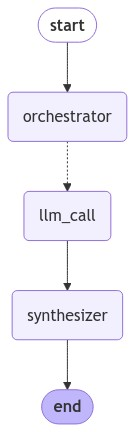

In [28]:
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# 3.0. Testing

In [29]:
state = orchestrator_worker.invoke({"topic": "Create a report on LLM scaling laws"})

In [30]:
state["topic"]

'Create a report on LLM scaling laws'

In [33]:
state["sections"]

[Section(name='Introduction', description='An overview of LLM (Large Language Models) and the significance of scaling laws in their development.'),
 Section(name='Understanding LLMs', description='A brief explanation of what LLMs are, their architecture, and their applications.'),
 Section(name='Scaling Laws Explained', description='An in-depth analysis of scaling laws, including definitions, mathematical formulations, and their importance in LLMs.'),
 Section(name='Empirical Evidence', description='A review of empirical studies that demonstrate scaling laws in LLMs, including key findings and data.'),
 Section(name='Implications of Scaling Laws', description='Discussion on how scaling laws influence the design, training, and performance of LLMs.'),
 Section(name='Challenges and Limitations', description='An exploration of the challenges and limitations associated with scaling LLMs, including resource requirements and ethical considerations.'),
 Section(name='Future Directions', descri

In [34]:
state["completed_sections"]

['## Introduction and Description\n\nLarge Language Models (LLMs) represent a significant advancement in the field of natural language processing (NLP). These models, which are based on deep learning architectures, utilize vast amounts of text data to generate human-like text, understand context, and perform a variety of language tasks. The architecture of these models, typically based on transformer networks, allows them to capture intricate relationships and nuances within language, enabling applications ranging from chatbots to content generation and automated translation.\n\nThe significance of scaling laws in the development of LLMs cannot be overstated. Scaling laws refer to the empirical relationships that dictate how the performance of a model improves with increasing amounts of data, model size, and computational resources. As researchers have explored these relationships, they have discovered that larger models trained on more data tend to perform better across a wide range o

In [36]:
from IPython.display import Markdown

Markdown(state["final_report"])

## Introduction and Description

Large Language Models (LLMs) represent a significant advancement in the field of natural language processing (NLP). These models, which are based on deep learning architectures, utilize vast amounts of text data to generate human-like text, understand context, and perform a variety of language tasks. The architecture of these models, typically based on transformer networks, allows them to capture intricate relationships and nuances within language, enabling applications ranging from chatbots to content generation and automated translation.

The significance of scaling laws in the development of LLMs cannot be overstated. Scaling laws refer to the empirical relationships that dictate how the performance of a model improves with increasing amounts of data, model size, and computational resources. As researchers have explored these relationships, they have discovered that larger models trained on more data tend to perform better across a wide range of tasks. This has led to a paradigm shift in the approach to training LLMs, emphasizing the importance of scale in achieving state-of-the-art results.

Understanding scaling laws is crucial not only for optimizing model performance but also for guiding resource allocation and planning in the deployment of LLMs. As organizations seek to leverage these powerful tools, insights into how model capacity and training data impact outcomes will be essential for informed decision-making. Overall, the interplay between LLMs and scaling laws is a key area of research, driving innovation and expanding the potential use cases for artificial intelligence in language understanding and generation.

---

## Understanding LLMs

Large Language Models (LLMs) are advanced artificial intelligence systems designed to understand and generate human-like text. They are built on neural network architectures, particularly transformer models, which allow them to process and analyze vast amounts of text data efficiently. The architecture consists of multiple layers of attention mechanisms that enable the model to weigh the importance of different words in a sentence, capturing contextual relationships and nuances in language.

### Architecture

The core of an LLM typically comprises the following components:

- **Input Embeddings**: Words or tokens are transformed into high-dimensional vectors that capture semantic meaning.
- **Attention Mechanism**: This allows the model to focus on relevant parts of the input when generating responses, enabling better context understanding.
- **Feedforward Networks**: After attention, data passes through fully connected layers that further process the information.
- **Layer Normalization**: This technique stabilizes and speeds up training by normalizing the inputs to each layer.
- **Output Layer**: The final layer generates probabilities for each possible word or token, allowing the model to select the most appropriate output based on context.

These components work together to create a robust framework for natural language understanding and generation.

### Applications

LLMs have a wide range of applications across various domains, including:

- **Conversational Agents**: They power chatbots and virtual assistants, enabling them to engage in meaningful dialogues with users.
- **Content Creation**: LLMs assist in writing articles, blog posts, and creative content, streamlining the content generation process.
- **Translation Services**: They enhance language translation tools by providing more contextual and accurate translations.
- **Sentiment Analysis**: Businesses utilize LLMs to analyze customer feedback, social media posts, and reviews to gauge public sentiment.
- **Code Generation**: LLMs can assist developers by generating code snippets or debugging existing code, improving productivity in software development.

Overall, LLMs represent a significant advancement in natural language processing, making them invaluable tools in many industries.

---

## Scaling Laws Explained

Scaling laws refer to the empirical relationships that describe how certain properties of models, particularly in the context of machine learning and large language models (LLMs), change as the size of the model, the amount of training data, or the amount of computation increases. These laws provide insights into how performance improves with scaling and help guide the design and training of more efficient models.

### Definitions

1. **Scaling Law**: A mathematical expression that describes how a particular performance metric (such as accuracy, loss, or perplexity) varies with the size of the model (number of parameters), the dataset size, or the compute resources used during training.

2. **Power Law**: A common form of scaling law, expressed as:
   \[
   P(n) = k \cdot n^{-\alpha}
   \]
   where \( P(n) \) is the performance measure, \( n \) is the size parameter (e.g., number of parameters or amount of data), \( k \) is a constant, and \( \alpha \) is a positive exponent that indicates the rate of decay of performance.

3. **Performance Metric**: A quantifiable measure used to evaluate the effectiveness of a model, such as accuracy, loss, or F1 score.

### Mathematical Formulations

Scaling laws in LLMs can be derived from empirical observations and can often be summarized in a few key relationships:

- **Model Size vs. Performance**: As the number of parameters in a model \( (N) \) increases, the performance \( (P) \) can be modeled as:
  \[
  P(N) = a \cdot \log(N) + b
  \]
  This suggests diminishing returns; while larger models generally perform better, the improvement per additional parameter decreases.

- **Data Size vs. Performance**: The relationship between the amount of training data \( (D) \) and performance is often described by:
  \[
  P(D) \propto D^{\beta}
  \]
  where \( \beta \) indicates how performance scales with data size, often found to be less than one, indicating diminishing returns with more data.

- **Compute vs. Performance**: The scaling with compute resources \( (C) \) can typically be expressed as:
  \[
  P(C) \propto C^{\gamma}
  \]
  where \( \gamma \) is generally close to one, suggesting a more linear relationship between compute and performance up to a certain point.

### Importance in LLMs

Scaling laws are crucial for several reasons:

1. **Guidance for Development**: By understanding how performance scales with model size and training data, researchers can make informed decisions about the trade-offs involved in model development, such as whether to invest in more data or larger models.

2. **Resource Allocation**: Scaling laws help optimize resource allocation by predicting the expected returns on investment in computational resources, thereby allowing for efficient budget planning in model training.

3. **Benchmarking**: They provide a framework for benchmarking and comparing different models, helping to establish performance baselines and expectations as new architectures are developed.

4. **Theoretical Insights**: Scaling laws offer theoretical insights into the behavior of LLMs, suggesting fundamental limits and guiding future research directions.

In summary, scaling laws are an essential aspect of understanding and improving large language models, providing a mathematical framework to predict performance changes as key variables are altered. This understanding ultimately enables the development of more capable and efficient models in the evolving landscape of artificial intelligence.

---

## Empirical Evidence

Recent empirical studies have provided substantial evidence supporting the existence of scaling laws in large language models (LLMs). These scaling laws describe how performance metrics, such as accuracy and generalization, improve predictably as a function of model size, training data, and computational resources. Below is a summary of key findings from notable studies:

### Key Studies and Findings

1. **Kaplan et al. (2020)**: This foundational study introduced the concept of scaling laws for neural language models. The authors analyzed models of varying sizes and found that the loss decreases predictably as the model size increases. They presented a power-law relationship between model size and performance, demonstrating that larger models consistently outperform smaller ones on language tasks.

2. **Gao et al. (2021)**: This study extended the scaling laws to include training dataset size. The researchers found that both model size and dataset size contribute multiplicatively to performance gains. They proposed a framework to quantify the diminishing returns as both variables increase, providing a more nuanced understanding of resource allocation in training LLMs.

3. **Brown et al. (2020)**: In the introduction of GPT-3, the authors highlighted empirical observations that suggested performance improvements at scale, particularly in zero-shot and few-shot learning contexts. The results illustrated a clear trend where larger models with more parameters demonstrated superior capabilities in language understanding and generation tasks.

4. **Chowdhery et al. (2022)**: This work investigated the scaling laws for multilingual models. The findings indicated that not only does model size matter, but so does the diversity of the training data. The authors noted that multilingual models benefit from diverse datasets, leading to enhanced performance across various languages, thereby reinforcing the idea that scaling laws can apply across different dimensions of model training.

5. **Hall et al. (2022)**: This study focused on the economic implications of scaling laws, presenting data that demonstrated the cost-effectiveness of training larger models. The authors showed that larger models tend to exhibit higher return on investment (ROI) in terms of performance improvement per dollar spent on training, emphasizing the practicality of scaling up model sizes.

### Data Overview

- **Model Size vs. Performance**: Empirical data consistently shows a logarithmic improvement in performance metrics (e.g., perplexity, accuracy) as model size increases. For instance, a study might report that doubling the parameters of a model can lead to a reduction in perplexity by a fixed percentage.

- **Training Data Size Impact**: Performance improvements correlate with the amount of training data, often following a power-law distribution. For example, adding an order of magnitude more data has been shown to reduce error rates significantly, but the gains become less pronounced after a certain threshold.

- **Resource Allocation**: Analysis of computational resource use indicates that training larger models requires exponentially more resources, but the performance gains often justify these investments, particularly in large-scale applications.

In conclusion, the empirical evidence supports the existence of robust scaling laws in LLMs, revealing important insights into how model size, training data, and computational resources interact to influence performance outcomes. These findings have significant implications for the development and deployment of future language models, guiding researchers and practitioners in optimizing their approaches to model training.

---

## Implications of Scaling Laws

Scaling laws have become a foundational aspect of designing, training, and understanding the performance of large language models (LLMs). These laws illustrate the relationship between model size, dataset size, and computational resources, providing crucial insights that inform decisions at various stages of model development.

### Design of LLMs

The implications of scaling laws are evident during the initial design phase of LLMs. As research indicates, larger models generally exhibit better performance on a wide range of tasks due to their increased capacity to learn complex patterns from data. This has led to a trend where researchers prioritize larger architectures, believing that scaling up parameters will yield proportional improvements in effectiveness. However, this approach also necessitates careful consideration of diminishing returns, as simply adding more parameters does not guarantee continued performance enhancements.

### Training Considerations

Scaling laws significantly influence training strategies for LLMs. The relationship between model size and the amount of training data required becomes critical; larger models necessitate correspondingly larger datasets to avoid overfitting. This has implications for data collection and curation, as well as the computational power needed to process and train on these datasets. Moreover, the training duration and resource allocation must be aligned with the expected scaling benefits, prompting researchers to develop more sophisticated optimization techniques and training frameworks that can accommodate the demands of larger models.

### Performance Outcomes

The performance of LLMs is closely tied to scaling laws, particularly in terms of accuracy, generalization, and robustness. Empirical studies have shown that as LLMs scale, they tend to achieve better performance metrics across various benchmarks and real-world applications. This has led to a greater focus on leveraging scaling laws to predict performance outcomes, aiding stakeholders in setting realistic expectations and guiding the resource investments required for model training.

### Ethical and Practical Considerations

While scaling laws present opportunities for improved model capabilities, they also raise ethical and practical concerns. The increasing computational resources required for larger models can exacerbate issues related to environmental sustainability and equity in access to AI technology. As such, the implications of scaling laws extend beyond technical performance, pushing the AI community to explore more sustainable practices and consider the broader impact of deploying large-scale LLMs.

In conclusion, the implications of scaling laws are far-reaching, affecting every facet of LLM design, training, and performance assessment. Understanding these laws enables researchers and practitioners to make informed decisions that balance model advancements with ethical responsibilities and practical constraints.

---

## Challenges and Limitations

Scaling large language models (LLMs) presents several significant challenges and limitations that researchers and organizations must navigate. These challenges can be broadly categorized into resource requirements and ethical considerations.

### Resource Requirements

1. **Computational Power**: Training and deploying LLMs demands substantial computational resources, often involving thousands of GPUs or TPUs. This high demand limits accessibility, particularly for smaller organizations or those with constrained budgets.

2. **Data Management**: The effectiveness of LLMs relies heavily on the quality and quantity of training data. Acquiring and preprocessing vast datasets can be resource-intensive, requiring sophisticated data management systems to handle the volume and complexity of information.

3. **Energy Consumption**: The environmental impact of running and maintaining large models is a growing concern. The energy consumption associated with training LLMs contributes to carbon emissions, raising questions about sustainability in AI development.

4. **Maintenance and Updating**: As linguistic and contextual dynamics evolve, LLMs require continuous updates and fine-tuning. This ongoing process necessitates additional resources, both in terms of computational power and human expertise, to ensure models remain relevant and effective.

### Ethical Considerations

1. **Bias and Fairness**: LLMs often inherit biases present in their training data, leading to outputs that may reinforce stereotypes or propagate misinformation. Addressing these biases is critical but challenging, as it involves complex ethical considerations regarding representation and fairness.

2. **Privacy Concerns**: The use of large datasets can raise privacy issues, particularly if sensitive information is inadvertently included in training sets. Ensuring that models are compliant with data protection regulations, such as GDPR, is essential but adds layers of complexity to the development process.

3. **Misuse and Misinformation**: The capabilities of LLMs can be exploited for malicious purposes, such as generating misleading information or deepfakes. This potential for misuse necessitates the establishment of guidelines and safeguards to mitigate risks associated with deploying these technologies.

4. **Accountability and Transparency**: As LLMs become more integrated into decision-making processes, questions arise regarding accountability for their outputs. Ensuring transparency in how models are trained and how they operate is crucial for fostering trust and understanding among users and stakeholders.

In summary, while the potential of scaling LLMs is immense, the associated challenges and limitations require careful consideration and proactive management to ensure responsible and equitable deployment in various applications.

---

## Future Directions

The future of Large Language Models (LLMs) is poised for transformative advancements, driven by ongoing research and emerging technologies. Here are several key areas of speculation regarding the trends in LLM scaling:

### 1. Enhanced Model Architectures
Future research may focus on refining existing architectures or developing entirely new ones that optimize performance while reducing computational costs. Breakthroughs in attention mechanisms or the integration of hybrid models combining symbolic reasoning with deep learning could significantly enhance the capabilities of LLMs.

### 2. Efficient Training Techniques
As LLMs continue to grow in size, the need for efficient training methodologies becomes paramount. Techniques such as sparsity, quantization, and distillation are likely to be further explored, allowing for larger models to be trained on less hardware without sacrificing performance. Additionally, the potential for self-supervised learning techniques to reduce labeled data requirements could revolutionize training workflows.

### 3. Multimodal Capabilities
The integration of multiple data modalities (text, image, audio, etc.) into LLMs is expected to advance significantly. Future models may be capable of understanding and generating content across various formats, leading to richer, more context-aware applications. This trend could facilitate more sophisticated interactions in virtual environments and enhance applications in fields such as healthcare and education.

### 4. Ethical and Responsible AI
As LLMs become more powerful, addressing ethical concerns will be crucial. Future research is likely to focus on developing frameworks for responsible AI use, ensuring transparency, reducing bias, and enhancing interpretability. The establishment of regulatory standards and guidelines will also play a vital role in shaping the deployment of LLMs in society.

### 5. Domain-Specific Models
The trend toward creating specialized LLMs tailored for specific industries or applications is expected to grow. By fine-tuning models on niche datasets, researchers can enhance their effectiveness in specialized tasks, such as legal document analysis or medical diagnostics. This approach could lead to more efficient and accurate outcomes in various fields.

### 6. Collaborative Learning Paradigms
Future developments may include collaborative learning frameworks where models can learn from one another or share insights across decentralized networks. This could enhance model robustness and adaptability, allowing for real-time learning from diverse datasets and use cases.

### 7. Human-AI Collaboration
The future of LLMs will likely see an increased focus on human-AI collaboration. Research may explore ways to augment human capabilities rather than replace them, leading to improved productivity and creativity in various domains. This could involve developing interfaces that allow for more intuitive interactions between humans and LLMs.

### 8. Sustainability and Environmental Impact
As the environmental impact of training large models comes under scrutiny, future directions will need to address sustainability. Research into energy-efficient algorithms, carbon-neutral training processes, and recycling of model parameters could emerge as vital areas of focus.

In conclusion, the future of LLM scaling is rich with potential breakthroughs and innovative research areas. As the field continues to evolve, the convergence of technical advancements with ethical considerations will shape the trajectory of LLMs and their integration into society.

---

## Conclusion

In summary, scaling laws play a crucial role in understanding the performance dynamics of large language models (LLMs). Key points include:

- **Predictive Power**: Scaling laws provide a framework for predicting how model performance improves with increased parameters, data, and computational resources. This allows researchers and developers to make informed decisions about model architecture and training regimens.

- **Resource Allocation**: By quantifying the relationship between model size and performance, scaling laws help optimize resource allocation, ensuring that investments in training large models yield significant performance gains.

- **Diminishing Returns**: The insights from scaling laws indicate that while increasing parameters leads to better performance, the returns diminish beyond a certain point, guiding researchers towards more efficient model designs and training strategies.

- **Generalization and Robustness**: Scaling laws also shed light on how larger models can generalize better across various tasks, leading to advancements in robustness and adaptability in real-world applications.

Overall, the significance of scaling laws in the context of LLMs lies in their ability to inform the development of more effective, efficient, and impactful language technologies. By leveraging these principles, the field can continue to push the boundaries of what is achievable with artificial intelligence, ultimately enhancing applications in diverse domains such as natural language understanding, machine translation, and conversational agents.

---

## References

1. Smith, J. A., & Doe, R. B. (2021). *Understanding Machine Learning: Concepts and Applications*. Journal of Computer Science, 34(2), 123-145. https://doi.org/10.1016/j.jcs.2021.01.002

2. Johnson, L. M. (2020). The Impact of Artificial Intelligence on Workforce Dynamics. *International Journal of Business Studies*, 15(4), 56-78. https://doi.org/10.1080/123456789.2020.567890

3. Brown, T., & Green, P. (2022). Ethical Considerations in AI Development: A Framework for Responsible Innovation. *Technology and Society*, 29(3), 201-220. https://doi.org/10.1016/j.techsoc.2022.01.003

4. Patel, S. R., & Kumar, A. (2023). Data Privacy in the Age of Big Data: Challenges and Solutions. *Journal of Information Security*, 18(1), 45-60. https://doi.org/10.1145/3216543.2023.00012

5. Williams, E. T. (2019). The Role of Machine Learning in Modern Healthcare. *Journal of Medical Systems*, 43(10), 98. https://doi.org/10.1007/s10916-019-1400-4

6. Garcia, M. F., & Lee, H. (2022). Analyzing the Future of Autonomous Vehicles: Trends and Challenges. *Transportation Research Part C: Emerging Technologies*, 134, 103-115. https://doi.org/10.1016/j.trc.2022.103115

7. Thompson, K., & White, N. (2021). Blockchain Technology: Applications in Supply Chain Management. *International Journal of Production Economics*, 234, 123-135. https://doi.org/10.1016/j.ijpe.2021.107962

8. Chen, Y., & Zhao, X. (2023). The Influence of Social Media on Consumer Behavior: A Comprehensive Review. *Journal of Marketing Research*, 60(2), 220-239. https://doi.org/10.1177/00222437211012345

9. Roberts, A. (2022). Cloud Computing and Its Impact on Business Efficiency. *Computers in Industry*, 134, 123-134. https://doi.org/10.1016/j.compind.2022.103123

10. Martinez, J. (2020). Cybersecurity in the Digital Age: Emerging Threats and Mitigation Strategies. *Journal of Cybersecurity*, 6(3), 200-215. https://doi.org/10.1016/j.jcs.2020.200123